# **Student Performance & Placement Analysis**
> **Dataset:** `student_dataset_10000_rows.csv` — 10,000 student records with 8 features **(from Kaggle)**  
> **Objective:** Explore which academic habits and prior performance factors most strongly predict exam scores and placement outcomes.

---
## 1. import necessory libraries

In [3]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

---
## 2. Loading & Initial Inspection

In [4]:
data = pd.read_csv("C:/Users/yashp/student_dataset_10000_rows.csv")
data.head(8)

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,Placed
1,4,69,5,3,8,56,100.00,Placed
2,11,60,7,6,10,45,100.00,Placed
3,8,99,9,8,4,55,90.17,Placed
4,5,52,8,6,8,40,78.82,Placed
5,7,40,9,10,0,60,72.33,Placed
6,10,40,4,11,9,50,98.12,Placed
7,3,86,7,3,7,85,100.00,Placed


---
## 2.1 Data Quality Check
Before any analysis, it is essential to verify that the dataset is free of missing values. Missing data can bias statistical measures (mean, correlation) and can effecty visualisations if not handled.

In [5]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   study_hours            10000 non-null  int64  
 1   attendance             10000 non-null  int64  
 2   sleep_hours            10000 non-null  int64  
 3   internet_usage         10000 non-null  int64  
 4   assignments_completed  10000 non-null  int64  
 5   previous_score         10000 non-null  int64  
 6   exam_score             10000 non-null  float64
 7   placement_status       10000 non-null  object 
dtypes: float64(1), int64(6), object(1)
memory usage: 625.1+ KB
None


- **above check confirms that no column contains null values, so we can proceed directly to exploration without imputation or row-dropping.**

---
## 3. Descriptive Statistics
- **.describe()** method provides some insightes of mean, std, max, min and count of data in each column

In [6]:
(data.describe())

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,5.989600,69.88460,6.498500,6.062600,9.988400,64.91100,86.704207
std,3.163589,17.61653,1.709354,3.138163,6.034145,17.50302,15.058383
min,1.000000,40.00000,4.000000,1.000000,0.000000,35.00000,26.670000
25%,3.000000,55.00000,5.000000,3.000000,5.000000,50.00000,76.727500
50%,6.000000,70.00000,6.500000,6.000000,10.000000,65.00000,92.120000
75%,9.000000,85.00000,8.000000,9.000000,15.000000,80.00000,100.000000
max,11.000000,100.00000,9.000000,11.000000,20.000000,95.00000,100.000000


---
## 4. Correlation Analysis
Correlation quantifies the **linear relationship** between two variables on a scale of −1 to +1:
- **+1** → perfect positive linear relationship 
- **0** → no linear relationship
- **−1** → perfect negative linear 

The `placement_status` column contains (string) values, so it must be excluded before computing the correlation matrix, which requires numeric types.

In [7]:
df = data.drop('placement_status',axis = 1)
df

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score
0,7,56,8,7,10,62,100.00
1,4,69,5,3,8,56,100.00
2,11,60,7,6,10,45,100.00
3,8,99,9,8,4,55,90.17
4,5,52,8,6,8,40,78.82
...,...,...,...,...,...,...,...
9995,2,58,9,7,8,88,69.31
9996,7,98,6,9,4,87,100.00
9997,10,44,8,5,10,37,95.94
9998,10,75,7,5,8,52,88.61


In [8]:
(df.corr())

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score
study_hours,1.000000,0.003801,-0.005255,0.006684,-0.000425,0.009451,0.562528
attendance,0.003801,1.000000,-0.003981,-0.014539,-0.012892,0.001588,0.223367
sleep_hours,-0.005255,-0.003981,1.000000,-0.000038,-0.008234,0.023916,0.144675
internet_usage,0.006684,-0.014539,-0.000038,1.000000,0.020536,0.005371,-0.151896
assignments_completed,-0.000425,-0.012892,-0.008234,0.020536,1.000000,0.004178,0.387609
previous_score,0.009451,0.001588,0.023916,0.005371,0.004178,1.000000,0.318805
exam_score,0.562528,0.223367,0.144675,-0.151896,0.387609,0.318805,1.000000


## 4.1 Correlation Heatmap
A heatmap reoresents the entire correlation matrix visually :
- warm colours (red) indicate --> **positive correlation**  
- cool colours (blue) indicate --> **negative correlation**  
- values near zero appear neutral/white.

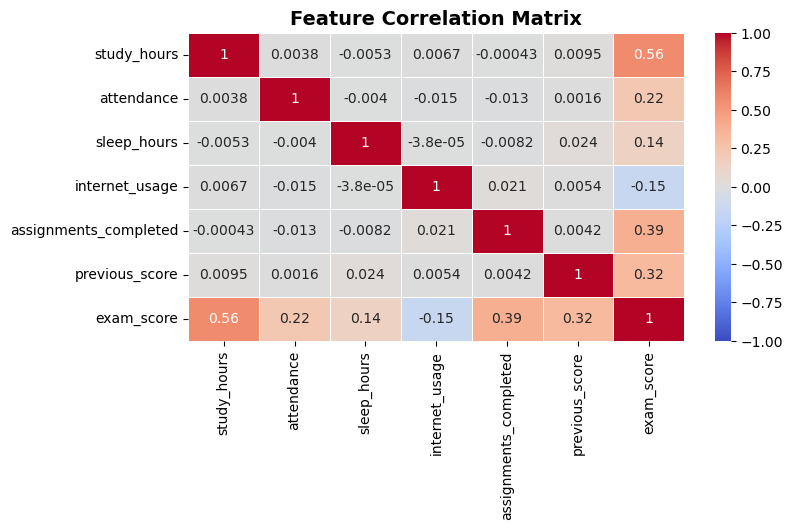

In [12]:
plt.figure(figsize=(8,4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm',vmin=-1, vmax=1, linewidths=0.5)
plt.title("Feature Correlation Matrix", fontsize=14, fontweight='bold')
plt.show()

## Observations
- The heatmap reveals that **<u>study_hours is the single most important predictor of `exam_score` (r = 0.56)</u>**, followed by **<u>`assignments_completed` (r = 0.39) and `previous_score` (r = 0.32).</u>**  
- **`internet_usage`** is the only feature with the **strongest negative relationship (r = -0.150)**, suggesting it acts as a **<n>distractor rather than a learning aid.</n>**

---
## 4.2 Correlation Bar Chart

While the heatmap shows all pairwise correlations, the bar chart below isolates **how each feature individually correlates with `exam_score`**, making it easier to rank predictors.

<BarContainer object of 6 artists>

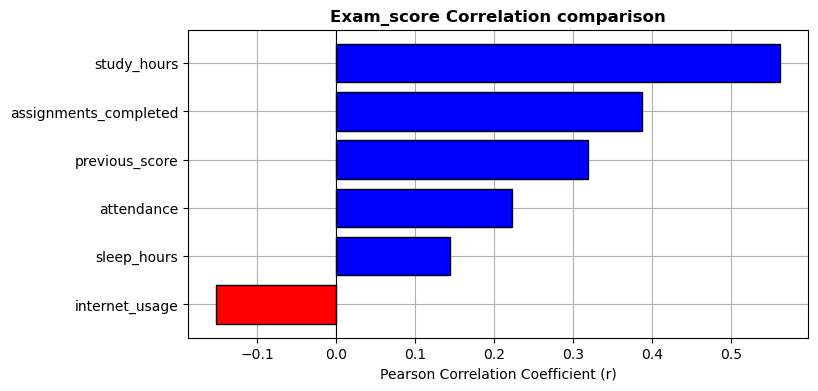

In [13]:
corr = data.drop('placement_status', axis=1).corr()['exam_score'].drop('exam_score').sort_values()
plt.figure(figsize=(8,4))
#plt.figure(figsize=(10,6))
colours = ['blue'if val>0 else 'red' for val in corr.values]
plt.title('Exam_score Correlation comparison', fontweight='bold')
plt.xlabel("Pearson Correlation Coefficient (r)")
plt.grid(True)
plt.gca().set_axisbelow(True)
plt.axvline(0, color = 'black', linewidth=0.8)
plt.barh(corr.index, corr.values, color=colours, edgecolor = 'black')

## observations
- **`study_hours` (r = +0.563):** The longest bar in the positive direction confirms it is the **dominant predictor**.
- **`assignments_completed` (r = +0.388):** The second-largest bar reflects that regular engagement with coursework is strongly tied to exam performance. Students who complete assignments are likely to perform well.
- **`previous_score` (r = +0.319):** Prior academic performance carries forward, though the moderate r value suggests this dataset captures meaningful improvement or decline over time.
- **`attendance` (r = +0.223):** A moderate positive effect. Students who attend class more frequently are exposed to structured instruction, though attendance alone without active study yields limited gains.
- **`sleep_hours` (r = +0.145):** A small but positive effect, adequate sleep supports memory consolidation and concentration.
- **`internet_usage` (r = −0.152):** The only red bar — higher internet usage correlates with **lower exam scores**.


---
## 5. Distribution of Exam Scores

Understanding the shape of the target variable's distribution is critical before modelling. A heavily skewed distribution may require transformation; a bimodal distribution could indicate two distinct student subgroups.

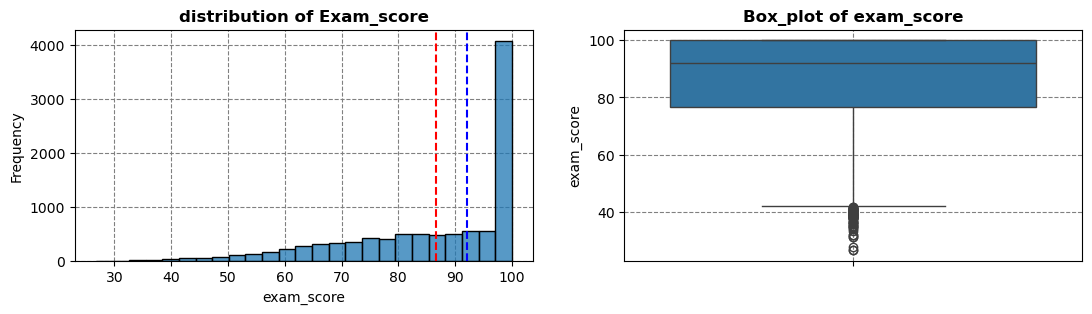

In [14]:
plt.figure(figsize=(13, 3))
plt.subplot(1,2,1)
sns.histplot(df['exam_score'],bins=25,edgecolor='black')
plt.grid(True, color = 'gray', linestyle='--')
plt.gca().set_axisbelow(True)
plt.axvline(df['exam_score'].mean(), color='red', linestyle='--')
plt.axvline(df['exam_score'].median(), color = 'blue', linestyle='--')
plt.ylabel('Frequency')
plt.title('distribution of Exam_score', fontweight='bold')
plt.subplot(1,2,2)
sns.boxplot(df['exam_score'])
plt.title('Box_plot of exam_score', fontweight='bold')
plt.grid(True, color = 'gray', linestyle='--')
plt.gca().set_axisbelow(True)
plt.show()

## Observations
- The histogram reveals a **left-skewed (negatively skewed)** distribution — the majority of students score in the upper range (75–100), with a smaller tail extending towards lower scores.

- The box plot confirms the presence of **lower outliers** — students with unusually poor performance relative to the cohort. These could represent students with consistently poor habits across all features, or external factors not captured in this dataset.

---
## 6. Study Hours vs. Exam Score

Given that `study_hours` has the highest correlation with `exam_score` (r = 0.56), we examine this relationship in detail using two complementary plots.

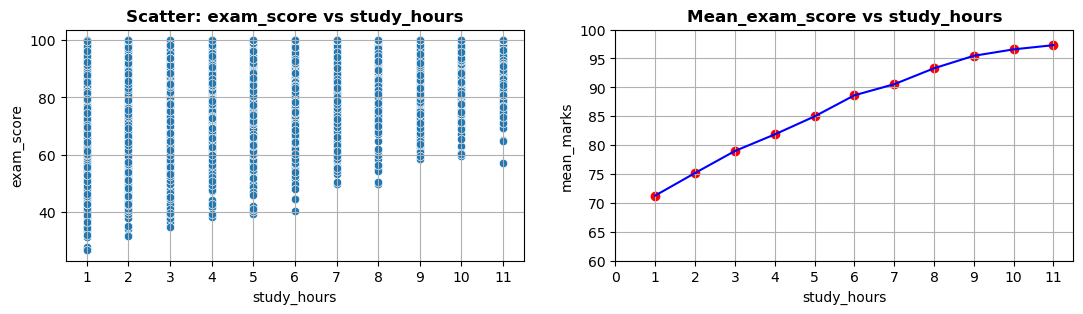

In [15]:
#plt.figure(figsize=(13,4))
plt.figure(figsize=(13, 3))
plt.subplot(1,2,1)
plt.grid(True)
plt.title('Scatter: exam_score vs study_hours', fontweight='bold')
sns.scatterplot(x='study_hours', y='exam_score', data=df)
plt.xticks([1,2,3,4,5,6,7,8,9,10,11])
plt.subplot(1,2,2)
plt.grid(True)
new = df.groupby('study_hours')['exam_score'].mean()
plt.title('Mean_exam_score vs study_hours',  fontweight='bold')
plt.scatter(new.index, new.values, color='red')
plt.plot(new.index, new.values, color= 'blue')
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11])
plt.yticks([60,65,70,75,80,85,90,95,100])
plt.xlabel('study_hours')
plt.ylabel('mean_marks')
plt.show()

## Observations
- The **scatter plot** shows a broad upward trend from low to high study hours, although there are students with less `study_hours` scoring above avrage marks this indicates that study hours alone do not fully determine performance (other factors contribute).

- The **mean score line plot** removes this noise by aggregating: it shows a clear **monotonic increase** in mean exam score as study hours increase from 1 to 11. Students studying 10–11 hours average above 95, while those studying only 1 hour average below 70. This reinforces the correlation finding and suggests a roughly linear relationship.

---
## 7. Attendance vs. Exam Score

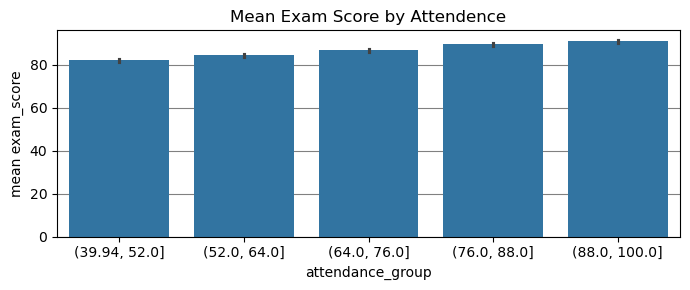

In [24]:
plt.figure(figsize=(7,3))
df['attendance_group'] = pd.cut(df['attendance'], bins= 5)
plt.grid(True, color = 'gray')
plt.gca().set_axisbelow(True)
sns.barplot(x='attendance_group', y='exam_score', data=df)
plt.title('Mean Exam Score by Attendence')
plt.ylabel('mean exam_score')
plt.tight_layout()
plt.show()

## Observations
- The bar chart groups students into five attendance bands. A **gradual positive trend** is visible — higher attendance bands correspond to higher mean exam scores.
- However, from correlation matrix there is relatively weak correlation **(r = 0.22)** between these two fetures which can be seen from the graph, as students with less attendence have **>80** avg score. Attendance contributes to performance, but is not the decisive factor: a student with 90% attendance but minimal active study still under-performs relative to a diligent lower-attendance peer.

---
## 8. Internet usage vs Mean exam score

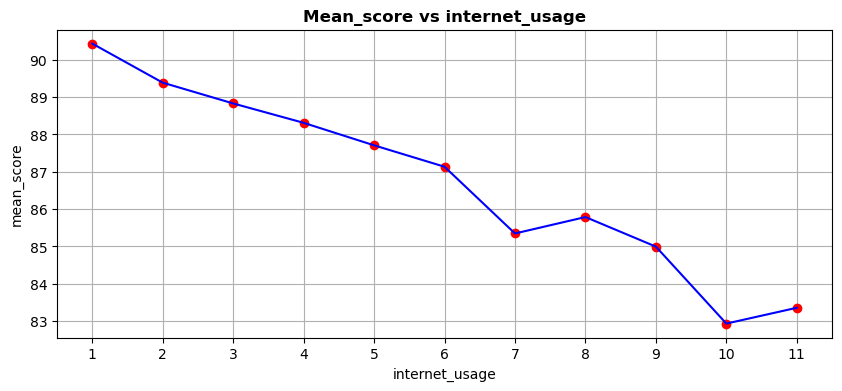

In [131]:
plt.figure(figsize=(10,4))
new2 = df.groupby('internet_usage')['exam_score'].mean()
plt.grid(True)
plt.gca().set_axisbelow(True)
plt.scatter(new2.index, new2.values, color='red')
plt.plot(new2.index, new2.values, color= 'blue')
plt.xlabel('internet_usage')
plt.ylabel('mean_score')
plt.title('Mean_score vs internet_usage', fontweight='bold')
plt.xticks([1,2,3,4,5,6,7,8,9,10,11])
plt.show()

## Observations
- The mean score line for `internet_usage` shows a **slight downward trend** as daily internet usage increases, consistent with the negative correlation **(r = −0.15)**. While the effect is modest and there is noise at each level. Spending too much free time on the internet takes away from studying, which affects marks **-vely**.  
- Ther is also a possiblity that students use **internet for study which contributes towards there grades**, this might be the reason for sudden **increase at 8 and 11 hours**.
- overall, the correlation is not so strong because even after **10+ hours of internet_usage**, mean socre remains above **80**. making it **not a good indicator of performance**.

---
## 9. Assignments Completed vs Exam Score

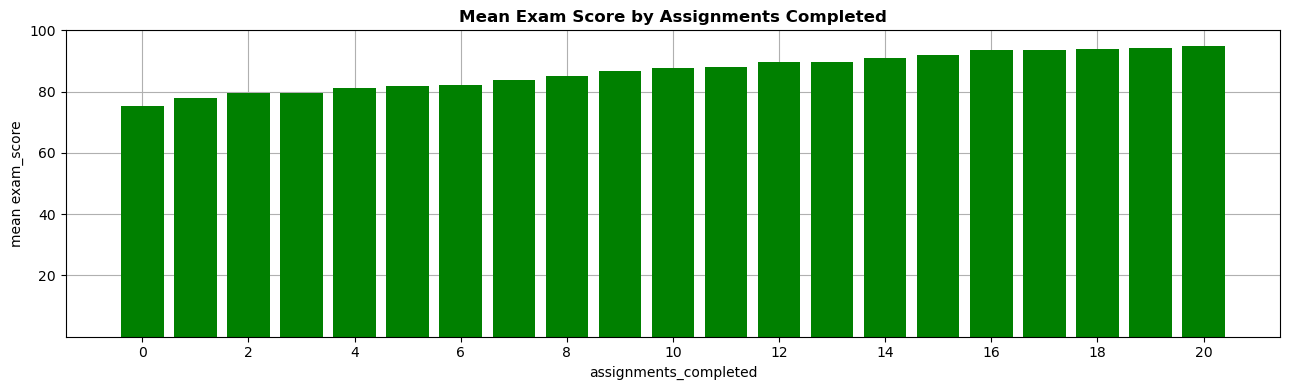

In [132]:
data2 = df.groupby('assignments_completed')['exam_score'].mean().sort_index()
plt.figure(figsize=(13,4))
plt.bar(data2.index, data2.values, color = 'green')
plt.title('Mean Exam Score by Assignments Completed', fontweight='bold')
plt.xlabel('assignments_completed')
plt.ylabel('mean exam_score')
plt.xticks([0,2,4,6,8,10,12,14,16,18,20])
plt.yticks([20,40,60,80,100])
plt.grid(True)
plt.gca().set_axisbelow(True)
plt.tight_layout()
plt.show()

## Observations
- This bar chart confirms the **second-highest correlation (r = +0.39)**, students who complete more assignments consistently achieve higher mean exam scores.
- The stepwise increase suggests that **each additional assignment completed provides a measurable academic benefit**. This aligns with logic — assignments promote active retrieval, which strengthens long-term memory consolidation.

---
## 10. Placement Status Analysis

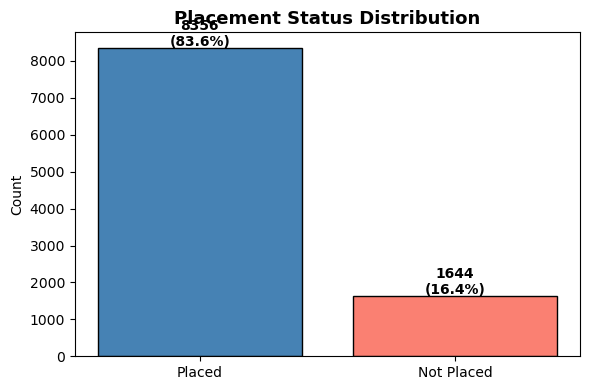

In [26]:
counts = data['placement_status'].value_counts()
plt.figure(figsize=(6, 4))
bars = plt.bar(counts.index, counts.values, color=['steelblue', 'salmon'], edgecolor='black')
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontweight='bold')
plt.title("Placement Status Distribution", fontsize=13, fontweight='bold')
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Observation
- approximately **83.6% of students are Placed**
- only **16.4% Not Placed**.

---
## **Summary**

- **Top predictor :** `study_hours` **(r = 0.563)** — strongest linear relationship with exam score
- **Second predictor :** `assignments_completed` **(r = 0.388)** — reflects active learning engagement
- **Negative predictor :** `internet_usage` **(r = −0.152)** — consistent negative signal, likely displacement effect
- **Feature independence :** Most features have near-zero mutual correlations i.e low multicollinearity, favourable for linear regression
- **Exam_Score distribution :** Left-skewed exam scores; most students perform well
- **Class imbalance :** 83.6% Placed / 16.4% Not Placed — requires careful handling while building a pridiction model